# Synthea EDA - FaithfulMed (Google 2D)

Owner: Renita | September milestone, Task #6

**What this notebook is for:** This notebook explores the Synthea synthetic clinical dataset to understand:

- how many synthetic patients are represented
- what clinical tables/resources are available
- how many records each resource contains
- the distribution of clinical events across patients
- conditions, medications, observations, procedures, encounters, and care plans
- missing values and basic data quality
- how a patient's records can be organized chronologically
- what information may need to be extracted/flattened before being given to an LLM

> **Important:** This is exploratory analysis, not predictive modeling. The purpose is to understand the structure and content of the data so we can later design a reliable Synthea/FHIR flattener for FaithfulMed.

## 1. Setup

The Synthea CSV files can be downloaded from their website under patient data. Synthea Website: https://synthetichealth.github.io/synthea/

This notebook assumes the Synthea CSV files are stored in:

```text
FaithfulMed/
├── data/
│   └── synthea/
│       ├── patients.csv
│       ├── encounters.csv
│       ├── conditions.csv
│       ├── medications.csv
│       ├── observations.csv
│       ├── procedures.csv
│       ├── careplans.csv
│       └── ...
└── notebooks/
    └── exploratory-data-analysis/
        └── synthea_eda.ipynb
```

If your folder has a different name or location, change `DATA_DIR` below.


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path from notebooks/synthea_eda.ipynb to data/synthea/
DATA_DIR = Path("../../data/synthea")

# Check that the directory exists
print("Data directory:", DATA_DIR.resolve())
print("Exists:", DATA_DIR.exists())

# List CSV files
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(f"\nFound {len(csv_files)} CSV files:")
for file in csv_files:
    print(" -", file.name)


Data directory: /Users/renitajustin/Desktop/personal-projects/google-faithfulmed/data/synthea
Exists: True

Found 16 CSV files:
 - allergies.csv
 - careplans.csv
 - conditions.csv
 - devices.csv
 - encounters.csv
 - imaging_studies.csv
 - immunizations.csv
 - medications.csv
 - observations.csv
 - organizations.csv
 - patients.csv
 - payer_transitions.csv
 - payers.csv
 - procedures.csv
 - providers.csv
 - supplies.csv


## 2. Load the datasets

We first load every CSV file that Synthea provided into a dictionary.


In [6]:
# Load every CSV into a dictionary
tables = {}

for file in csv_files:
    try:
        tables[file.stem] = pd.read_csv(file)
    except Exception as e:
        print(f"Could not load {file.name}: {e}")

print(f"Loaded {len(tables)} tables.")
print(list(tables.keys()))


Loaded 16 tables.
['allergies', 'careplans', 'conditions', 'devices', 'encounters', 'imaging_studies', 'immunizations', 'medications', 'observations', 'organizations', 'patients', 'payer_transitions', 'payers', 'procedures', 'providers', 'supplies']


## 3. Dataset overview

The first questions to answer are:

1. How many patients are there?
2. How many rows are in each clinical table?
3. How many columns does each table have?

This distinction is important: **the number of patients is not the number of clinical records**. One patient can have many encounters, conditions, medications, observations, etc.


In [7]:
# Display shape of every table
overview = pd.DataFrame({
    "table": list(tables.keys()),
    "rows": [df.shape[0] for df in tables.values()],
    "columns": [df.shape[1] for df in tables.values()]
}).sort_values("rows", ascending=False)

overview


,table,rows,columns
8,observations,299697,8
4,encounters,53346,15
7,medications,42989,13
13,procedures,34981,8
6,immunizations,15478,6
2,conditions,8376,6
14,providers,5855,12
11,payer_transitions,3801,5
1,careplans,3483,9
10,patients,1171,25


### Patient count

Synthea tables generally connect back to patients through a patient identifier. We should count unique patient IDs rather than simply counting rows.


In [8]:
patients = tables.get("patients")

if patients is not None:
    print("Patient table shape:", patients.shape)
    print("Columns:")
    print(patients.columns.tolist())

    # Synthea commonly uses "Id" for the patient identifier.
    patient_id_col = next(
        (col for col in ["Id", "ID", "id"] if col in patients.columns),
        None
    )

    if patient_id_col:
        print("\nUnique synthetic patients:", patients[patient_id_col].nunique())
    else:
        print("\nCould not automatically identify the patient ID column.")
else:
    print("patients.csv was not found.")


Patient table shape: (1171, 25)
Columns:
['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']

Unique synthetic patients: 1171


## 4. Inspect the patient table

Before plotting anything, inspect the first few rows, data types, and summary statistics.


In [9]:
if patients is not None:
    display(patients.head())
    print("\nData types:")
    display(patients.dtypes)
    print("\nSummary:")
    display(patients.describe(include="all").T)


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,NaN,999-76-6866,S99984236,X19277260X,Mr.,José Eduardo181,Gómez206,NaN,...,Marigot Saint Andrew Parish DM,427 Balistreri Way Unit 19,Chicopee,Massachusetts,Hampden County,1013.0,42.228354,-72.562951,271227.08,1334.88
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,NaN,999-73-5361,S99962402,X88275464X,Mr.,Milo271,Feil794,NaN,...,Danvers Massachusetts US,422 Farrell Path Unit 69,Somerville,Massachusetts,Middlesex County,2143.0,42.360697,-71.126531,793946.01,3204.49
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,NaN,999-27-3385,S99972682,X73754411X,Mr.,Jayson808,Fadel536,NaN,...,Springfield Massachusetts US,1056 Harris Lane Suite 70,Chicopee,Massachusetts,Hampden County,1020.0,42.181642,-72.608842,574111.90,2606.40
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,NaN,999-85-4926,S99974448,X40915583X,Mrs.,Mariana775,Rutherford999,NaN,...,Yarmouth Massachusetts US,999 Kuhn Forge,Lowell,Massachusetts,Middlesex County,1851.0,42.636143,-71.343255,935630.30,8756.19
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,NaN,999-60-7372,S99915787,X86772962X,Mr.,Gregorio366,Auer97,NaN,...,Patras Achaea GR,1050 Lindgren Extension Apt 38,Boston,Massachusetts,Suffolk County,2135.0,42.352434,-71.028610,598763.07,3772.20



Data types:


Id                         str
BIRTHDATE                  str
DEATHDATE                  str
SSN                        str
DRIVERS                    str
PASSPORT                   str
PREFIX                     str
FIRST                      str
LAST                       str
SUFFIX                     str
MAIDEN                     str
MARITAL                    str
RACE                       str
ETHNICITY                  str
GENDER                     str
BIRTHPLACE                 str
ADDRESS                    str
CITY                       str
STATE                      str
COUNTY                     str
ZIP                    float64
LAT                    float64
LON                    float64
HEALTHCARE_EXPENSES    float64
HEALTHCARE_COVERAGE    float64
dtype: object


Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1171,1171,1d604da9-9a81-4ba9-80c2-de3375d59b40,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIRTHDATE,1171,982,1942-05-23,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEATHDATE,171,171,2012-11-21,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,1171,1170,999-56-8425,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DRIVERS,958,952,S99958686,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PASSPORT,898,898,X19277260X,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PREFIX,927,3,Mr.,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FIRST,1171,992,Mickey576,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LAST,1171,490,Douglas31,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SUFFIX,12,3,JD,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Patient demographics

Synthea patient data can contain demographic attributes such as gender, race, ethnicity, birth date, and geographic information.

For FaithfulMed, these fields are useful to understand because later evaluation may need to consider whether the system behaves consistently across different patient groups. We will keep this analysis descriptive rather than treating demographic variables as prediction targets.


In [10]:
# Show available demographic columns
if patients is not None:
    demographic_keywords = [
        "gender", "race", "ethnicity", "birth", "death",
        "marital", "city", "state", "county"
    ]

    demographic_cols = [
        col for col in patients.columns
        if any(keyword in col.lower() for keyword in demographic_keywords)
    ]

    print("Potential demographic columns:")
    print(demographic_cols)


Potential demographic columns:
['BIRTHDATE', 'DEATHDATE', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'CITY', 'STATE', 'COUNTY']


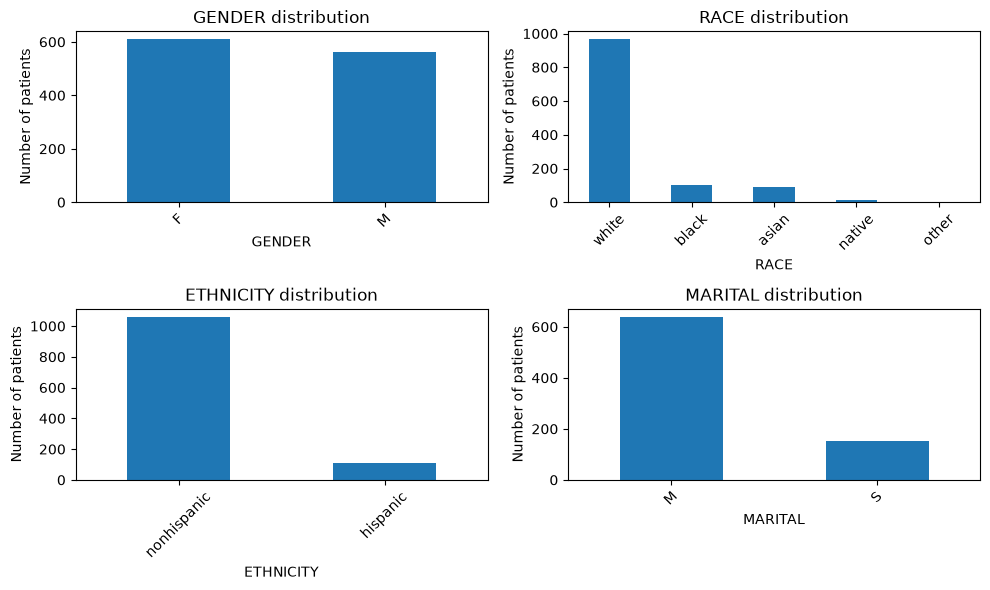

In [35]:
# Plot categorical demographic distributions when the columns exist
if patients is not None:
    categorical_cols = [
        col for col in ["GENDER", "RACE", "ETHNICITY", "MARITAL"]
        if col in patients.columns
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        patients[col].value_counts(dropna=True).plot(
            kind="bar",
            ax=axes[i]
        )
        axes[i].set_title(f"{col} distribution")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Number of patients")
        axes[i].tick_params(axis="x", rotation=45)

    # Hide unused plots if fewer than 4 columns exist
    for i in range(len(categorical_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


## 6. Clinical resource distribution

Now we move from patients to their clinical histories.

The key question is:

> **What types of clinical information make up a typical Synthea patient record?**

We will compare the number of rows in the major clinical tables.


,resource,records
3,observations,299697
0,encounters,53346
2,medications,42989
4,procedures,34981
7,immunizations,15478
1,conditions,8376
5,careplans,3483
6,allergies,597


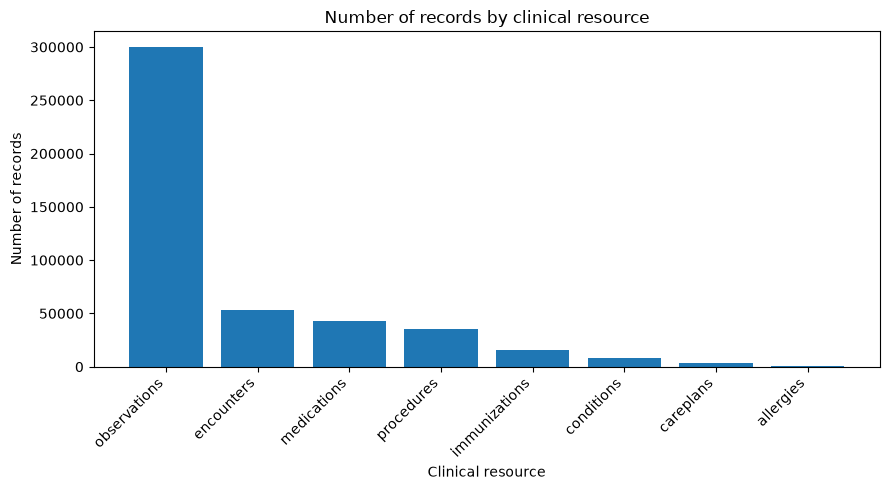

In [15]:
# Focus on common clinical tables if they exist
clinical_table_names = [
    "encounters",
    "conditions",
    "medications",
    "observations",
    "procedures",
    "careplans",
    "allergies",
    "immunizations"
]

clinical_counts = []

for name in clinical_table_names:
    if name in tables:
        clinical_counts.append({
            "resource": name,
            "records": len(tables[name])
        })

clinical_counts = pd.DataFrame(clinical_counts).sort_values(
    "records", ascending=False
)

display(clinical_counts)

plt.figure(figsize=(9, 5))
plt.bar(clinical_counts["resource"], clinical_counts["records"])
plt.title("Number of records by clinical resource")
plt.xlabel("Clinical resource")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 7. Records per patient

Raw row counts can be misleading. A table with 50,000 rows could represent 1,000 patients with 50 records each, or it could be concentrated among a much smaller group.

For each resource, calculate the number of records per patient and summarize its distribution.


In [16]:
# Identify the patient ID column in each table and summarize records per patient

def find_patient_column(df):
    candidates = [
        "PATIENT", "patient", "Patient",
        "PATIENT_ID", "patient_id",
        "Id", "ID", "id"
    ]
    return next((col for col in candidates if col in df.columns), None)


records_per_patient = []

for name, df in tables.items():
    patient_col = find_patient_column(df)

    if patient_col is not None and name != "patients":
        counts = df.groupby(patient_col).size()

        records_per_patient.append({
            "resource": name,
            "patients_with_records": counts.index.nunique(),
            "mean_records_per_patient": counts.mean(),
            "median_records_per_patient": counts.median(),
            "min_records_per_patient": counts.min(),
            "max_records_per_patient": counts.max()
        })

records_per_patient = pd.DataFrame(records_per_patient).sort_values(
    "mean_records_per_patient", ascending=False
)

records_per_patient


,resource,patients_with_records,mean_records_per_patient,median_records_per_patient,min_records_per_patient,max_records_per_patient
8,observations,1171,255.932536,164.0,34.0,9023.0
4,encounters,1171,45.555935,27.0,2.0,2006.0
7,medications,1107,38.833785,8.0,1.0,3313.0
12,procedures,1165,30.026609,9.0,1.0,1273.0
6,immunizations,1169,13.240376,12.0,1.0,36.0
2,conditions,1152,7.270833,7.0,1.0,25.0
0,allergies,141,4.234043,4.0,1.0,10.0
10,payer_transitions,983,3.866734,2.0,1.0,23.0
5,imaging_studies,247,3.461538,1.0,1.0,59.0
1,careplans,1054,3.304554,3.0,1.0,12.0


## 8. Encounters

Encounters provide an important backbone for understanding a patient's timeline.

Let's inspect the columns and encounter types available in this Synthea sample.


In [17]:
encounters = tables.get("encounters")

if encounters is not None:
    print("Shape:", encounters.shape)
    print("Columns:")
    print(encounters.columns.tolist())
    display(encounters.head())


Shape: (53346, 15)
Columns:
['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,d0c40d10-8d87-447e-836e-99d26ad52ea5,2010-01-23T17:45:28Z,2010-01-23T18:10:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e002090d-4e92-300e-b41e-7d1f21dee4c6,e6283e46-fd81-3611-9459-0edb1c3da357,6e2f1a2d-27bd-3701-8d08-dae202c58632,ambulatory,185345009,Encounter for symptom,129.16,129.16,54.16,10509002.0,Acute bronchitis (disorder)
1,e88bc3a9-007c-405e-aabc-792a38f4aa2b,2012-01-23T17:45:28Z,2012-01-23T18:00:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,772ee193-bb9f-30eb-9939-21e86c8e4da5,6f1d59a7-a5bd-3cf9-9671-5bad2f351c28,6e2f1a2d-27bd-3701-8d08-dae202c58632,wellness,162673000,General examination of patient (procedure),129.16,129.16,129.16,NaN,NaN
2,8f104aa7-4ca9-4473-885a-bba2437df588,2001-05-01T15:02:18Z,2001-05-01T15:17:18Z,1d604da9-9a81-4ba9-80c2-de3375d59b40,5d4b9df1-93ae-3bc9-b680-03249990e558,af01a385-31d3-3c77-8fdb-2867fe88df2f,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185345009,Encounter for symptom,129.16,129.16,0.00,36971009.0,Sinusitis (disorder)
3,b85c339a-6076-43ed-b9d0-9cf013dec49d,2011-07-28T15:02:18Z,2011-07-28T15:17:18Z,1d604da9-9a81-4ba9-80c2-de3375d59b40,3dc9bb2d-5d66-3e61-bf9a-e234c6433577,bb17e691-262b-3546-93d5-d88e7de93246,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),129.16,129.16,0.00,NaN,NaN
4,dae2b7cb-1316-4b78-954f-fa610a6c6d0e,2010-07-27T12:58:08Z,2010-07-27T13:28:08Z,10339b10-3cd1-4ac3-ac13-ec26728cb592,b03dba4f-892f-365c-bfd1-bfcfa7a98d5d,7ed6b84a-b847-3744-9d42-15c42297a0c2,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),129.16,129.16,129.16,NaN,NaN


In [18]:
if encounters is not None:
    # Look for a likely encounter-type column
    possible_type_cols = [
        col for col in encounters.columns
        if "type" in col.lower() or "class" in col.lower()
    ]

    print("Possible encounter-type columns:", possible_type_cols)

    for col in possible_type_cols:
        if encounters[col].nunique() <= 30:
            display(encounters[col].value_counts(dropna=False).to_frame("count"))


Possible encounter-type columns: ['ENCOUNTERCLASS']


,count
ENCOUNTERCLASS,
wellness,19106
ambulatory,18936
outpatient,9003
urgentcare,2373
emergency,2090
inpatient,1838


## 9. Conditions

Conditions are one of the most important resources for understanding what diagnoses appear in the synthetic population.

We will examine the most common condition descriptions.


In [19]:
conditions = tables.get("conditions")

if conditions is not None:
    print("Shape:", conditions.shape)
    print("Columns:", conditions.columns.tolist())
    display(conditions.head())


Shape: (8376, 6)
Columns: ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2001-05-01,NaN,1d604da9-9a81-4ba9-80c2-de3375d59b40,8f104aa7-4ca9-4473-885a-bba2437df588,40055000,Chronic sinusitis (disorder)
1,2011-08-09,2011-08-16,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,9d35ec9f-352a-4629-92ef-38eae38437e7,444814009,Viral sinusitis (disorder)
2,2011-11-16,2011-11-26,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,ae7555a9-eaff-4c09-98a7-21bc6ed1b1fd,195662009,Acute viral pharyngitis (disorder)
3,2011-05-13,2011-05-27,10339b10-3cd1-4ac3-ac13-ec26728cb592,e1ab4933-07a1-49f0-b4bd-05500919061d,10509002,Acute bronchitis (disorder)
4,2011-02-06,2011-02-14,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,b8f76eba-7795-4dcd-a544-f27ac2ef3d46,195662009,Acute viral pharyngitis (disorder)


,records
DESCRIPTION,
Viral sinusitis (disorder),1248
Acute viral pharyngitis (disorder),653
Acute bronchitis (disorder),563
Normal pregnancy,516
Body mass index 30+ - obesity (finding),449
Prediabetes,317
Hypertension,302
Anemia (disorder),300
Chronic sinusitis (disorder),236


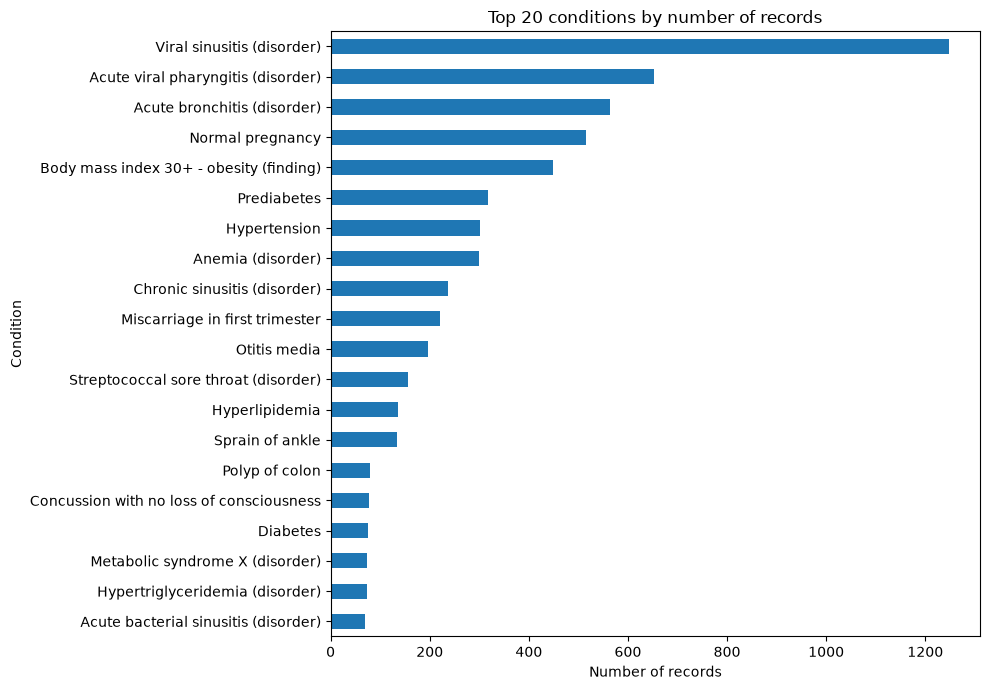

In [20]:
if conditions is not None:
    description_col = next(
        (col for col in ["DESCRIPTION", "description", "Condition", "condition"]
         if col in conditions.columns),
        None
    )

    if description_col:
        top_conditions = conditions[description_col].value_counts().head(20)

        display(top_conditions.to_frame("records"))

        plt.figure(figsize=(10, 7))
        top_conditions.sort_values().plot(kind="barh")
        plt.title("Top 20 conditions by number of records")
        plt.xlabel("Number of records")
        plt.ylabel("Condition")
        plt.tight_layout()
        plt.show()


## 10. Medications

Next, examine medication records and the most frequently occurring medications.


In [21]:
medications = tables.get("medications")

if medications is not None:
    print("Shape:", medications.shape)
    print("Columns:", medications.columns.tolist())
    display(medications.head())


Shape: (42989, 13)
Columns: ['START', 'STOP', 'PATIENT', 'PAYER', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'PAYER_COVERAGE', 'DISPENSES', 'TOTALCOST', 'REASONCODE', 'REASONDESCRIPTION']


,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2010-05-05T00:26:23Z,2011-04-30T00:26:23Z,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,1e0d6b0e-1711-4a25-99f9-b1c700c9b260,389221,Etonogestrel 68 MG Drug Implant,677.08,0.0,12,8124.96,NaN,NaN
1,2011-04-30T00:26:23Z,2012-04-24T00:26:23Z,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,6aa37300-d1b4-48e7-a2f8-5e0f70f48f38,389221,Etonogestrel 68 MG Drug Implant,624.09,0.0,12,7489.08,NaN,NaN
2,2012-04-24T00:26:23Z,2013-04-19T00:26:23Z,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,7253a9f9-6f6d-429a-926a-7b1d424eae3f,748856,Yaz 28 Day Pack,43.32,0.0,12,519.84,NaN,NaN
3,2011-05-13T12:58:08Z,2011-05-27T12:58:08Z,10339b10-3cd1-4ac3-ac13-ec26728cb592,d47b3510-2895-3b70-9897-342d681c769d,e1ab4933-07a1-49f0-b4bd-05500919061d,313782,Acetaminophen 325 MG Oral Tablet,8.14,0.0,1,8.14,10509002.0,Acute bronchitis (disorder)
4,2011-12-08T15:02:18Z,2011-12-22T15:02:18Z,1d604da9-9a81-4ba9-80c2-de3375d59b40,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,792fae81-a007-44b0-8221-46953737b089,562251,Amoxicillin 250 MG / Clavulanate 125 MG Oral T...,11.91,0.0,1,11.91,444814009.0,Viral sinusitis (disorder)


,records
DESCRIPTION,
Hydrochlorothiazide 25 MG Oral Tablet,3954
insulin human isophane 70 UNT/ML / Regular Insulin Human 30 UNT/ML Injectable Suspension [Humulin],3880
1 ML Epoetin Alfa 4000 UNT/ML Injection [Epogen],3388
Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet,3347
24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet,2895
amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet,2867
Simvastatin 10 MG Oral Tablet,2273
120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler,2072
NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler,2072


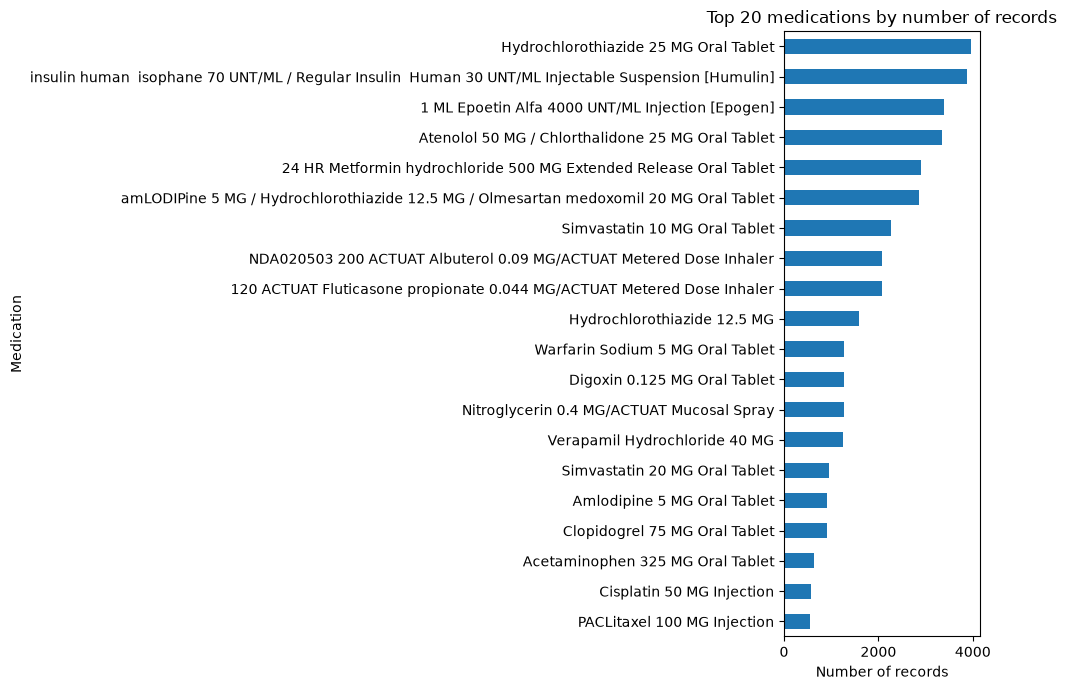

In [22]:
if medications is not None:
    description_col = next(
        (col for col in ["DESCRIPTION", "description", "Medication", "medication"]
         if col in medications.columns),
        None
    )

    if description_col:
        top_medications = medications[description_col].value_counts().head(20)
        display(top_medications.to_frame("records"))

        plt.figure(figsize=(10, 7))
        top_medications.sort_values().plot(kind="barh")
        plt.title("Top 20 medications by number of records")
        plt.xlabel("Number of records")
        plt.ylabel("Medication")
        plt.tight_layout()
        plt.show()


## 11. Observations and measurements

Observations may contain measurements such as laboratory results, vital signs, and other clinical observations.

Because observations can contain both categorical and numeric values, first inspect their schema before deciding how to analyze them.


In [23]:
observations = tables.get("observations")

if observations is not None:
    print("Shape:", observations.shape)
    print("Columns:")
    print(observations.columns.tolist())
    display(observations.head())


Shape: (299697, 8)
Columns:
['DATE', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'VALUE', 'UNITS', 'TYPE']


,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2012-01-23T17:45:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e88bc3a9-007c-405e-aabc-792a38f4aa2b,8302-2,Body Height,193.3,cm,numeric
1,2012-01-23T17:45:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e88bc3a9-007c-405e-aabc-792a38f4aa2b,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,2.0,{score},numeric
2,2012-01-23T17:45:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e88bc3a9-007c-405e-aabc-792a38f4aa2b,29463-7,Body Weight,87.8,kg,numeric
3,2012-01-23T17:45:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e88bc3a9-007c-405e-aabc-792a38f4aa2b,39156-5,Body Mass Index,23.5,kg/m2,numeric
4,2012-01-23T17:45:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e88bc3a9-007c-405e-aabc-792a38f4aa2b,8462-4,Diastolic Blood Pressure,82.0,mm[Hg],numeric


,records
DESCRIPTION,
Pain severity - 0-10 verbal numeric rating [Score] - Reported,16820
Diastolic Blood Pressure,12963
Systolic Blood Pressure,12963
Body Height,12552
Body Weight,12552
Heart rate,12552
Respiratory rate,12552
Tobacco smoking status NHIS,12552
Body Mass Index,11451


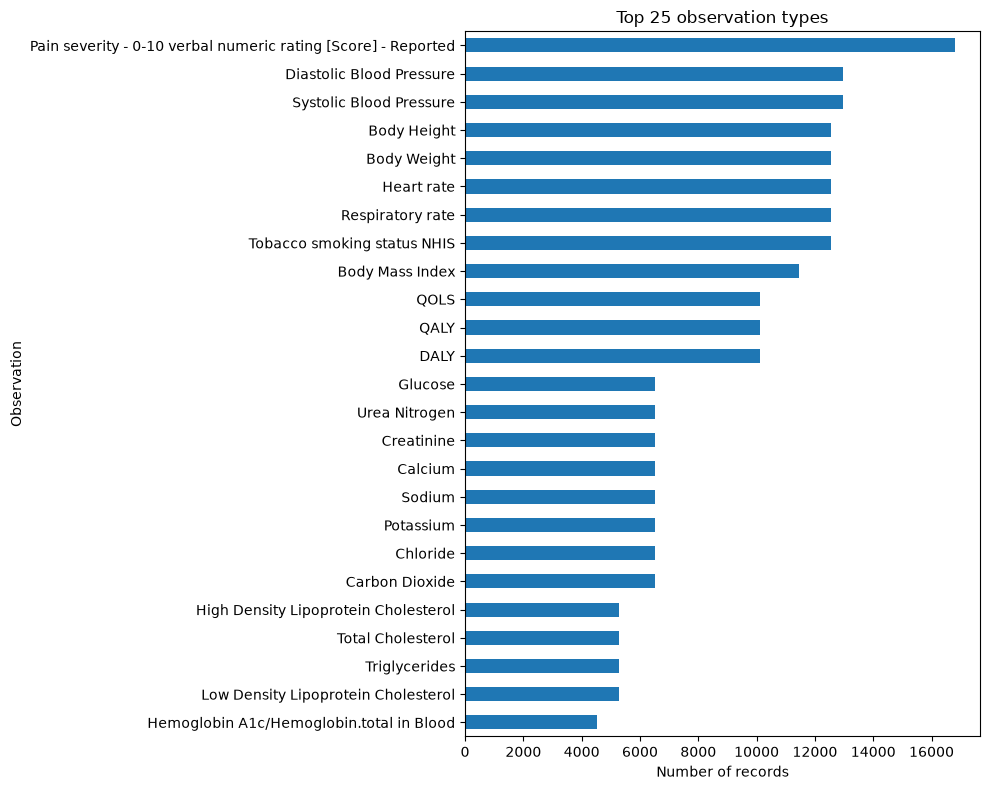

In [24]:
if observations is not None:
    description_col = next(
        (col for col in ["DESCRIPTION", "description"]
         if col in observations.columns),
        None
    )

    if description_col:
        top_observations = observations[description_col].value_counts().head(25)
        display(top_observations.to_frame("records"))

        plt.figure(figsize=(10, 8))
        top_observations.sort_values().plot(kind="barh")
        plt.title("Top 25 observation types")
        plt.xlabel("Number of records")
        plt.ylabel("Observation")
        plt.tight_layout()
        plt.show()


## 12. Procedures and care plans

These resources help describe what happened to a patient and what care was planned.

They are particularly relevant when thinking about how a clinical history could later be converted into a patient-friendly explanation.


In [25]:
for name in ["procedures", "careplans"]:
    df = tables.get(name)

    if df is not None:
        print(f"\n{name.upper()}")
        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())
        display(df.head(3))



PROCEDURES
Shape: (34981, 8)
Columns: ['DATE', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']


,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-04-30T00:26:23Z,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,6aa37300-d1b4-48e7-a2f8-5e0f70f48f38,169553002,Insertion of subcutaneous contraceptive,14896.56,NaN,NaN
1,2010-07-27T12:58:08Z,10339b10-3cd1-4ac3-ac13-ec26728cb592,dae2b7cb-1316-4b78-954f-fa610a6c6d0e,430193006,Medication Reconciliation (procedure),726.51,NaN,NaN
2,2010-11-20T03:04:34Z,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,7ff86631-0378-4bfc-92ce-1edd697eb18e,430193006,Medication Reconciliation (procedure),788.50,NaN,NaN



CAREPLANS
Shape: (3483, 9)
Columns: ['Id', 'START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']


,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
0,d2500b8c-e830-433a-8b9d-368d30741520,2010-01-23,2012-01-23,034e9e3b-2def-4559-bb2a-7850888ae060,d0c40d10-8d87-447e-836e-99d26ad52ea5,53950000,Respiratory therapy,10509002.0,Acute bronchitis (disorder)
1,07d9ddd8-dfa1-4e43-9bfe-39f63f4ace15,2011-05-13,2011-08-02,10339b10-3cd1-4ac3-ac13-ec26728cb592,e1ab4933-07a1-49f0-b4bd-05500919061d,53950000,Respiratory therapy,10509002.0,Acute bronchitis (disorder)
2,a3bb6e99-3b99-44b3-974c-e230b4511b5c,2011-12-31,2012-11-30,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,16300c56-a035-4126-a656-68c093da6dfc,53950000,Respiratory therapy,10509002.0,Acute bronchitis (disorder)


## 13. Missing values

Before using any clinical data for downstream LLM processing, we need to understand missingness.

We will calculate:

- missing count
- missing percentage

for every table.


In [26]:
def missing_summary(df):
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    })
    return result.sort_values("missing_percent", ascending=False)


# Example: patients table
if patients is not None:
    display(missing_summary(patients))


,missing_count,missing_percent
SUFFIX,1159,98.975235
DEATHDATE,1000,85.397096
MAIDEN,840,71.733561
ZIP,543,46.370623
MARITAL,380,32.450897
PASSPORT,273,23.313407
PREFIX,244,20.836892
DRIVERS,213,18.189582
Id,0,0.000000
ADDRESS,0,0.000000


In [27]:
# Find columns with substantial missingness across the clinical tables

missing_results = []

for name, df in tables.items():
    for col in df.columns:
        missing_pct = df[col].isna().mean() * 100

        missing_results.append({
            "table": name,
            "column": col,
            "missing_percent": missing_pct
        })

missing_results = pd.DataFrame(missing_results)

display(
    missing_results
    .query("missing_percent > 0")
    .sort_values("missing_percent", ascending=False)
    .head(50)
)


,table,column,missing_percent
22,devices,STOP,100.000000
100,patients,SUFFIX,98.975235
1,allergies,STOP,89.279732
93,patients,DEATHDATE,85.397096
41,encounters,REASONCODE,74.174259
42,encounters,REASONDESCRIPTION,74.174259
101,patients,MAIDEN,71.733561
111,patients,ZIP,46.370623
16,conditions,STOP,45.499045
148,procedures,REASONCODE,44.435551


## 14. Dates and patient timelines

One of the most important questions for FaithfulMed is:

> **Can a patient's clinical history be represented as a chronological sequence of events?**

Synthea tables commonly contain start/stop dates. We can inspect which tables contain date-like columns.


In [28]:
# Identify columns whose names suggest they contain dates
date_columns = []

for name, df in tables.items():
    for col in df.columns:
        if any(keyword in col.lower() for keyword in ["date", "start", "stop", "time"]):
            date_columns.append({
                "table": name,
                "column": col
            })

pd.DataFrame(date_columns)


,table,column
0,allergies,START
1,allergies,STOP
2,careplans,START
3,careplans,STOP
4,conditions,START
5,conditions,STOP
6,devices,START
7,devices,STOP
8,encounters,START
9,encounters,STOP


### Build a simple patient timeline

The exact column names can vary between Synthea exports, so the following cell first checks which columns are available.

This is an exploratory representation — **not yet the final FHIR flattener**.


In [29]:
def build_timeline(patient_id, tables):
    events = []

    for name, df in tables.items():
        patient_col = find_patient_column(df)

        if patient_col is None or name == "patients":
            continue

        patient_rows = df[df[patient_col] == patient_id]

        if patient_rows.empty:
            continue

        # Look for a likely start/date column
        date_col = next(
            (
                col for col in df.columns
                if col.lower() in [
                    "start", "date", "datetime", "timestamp"
                ]
                or "start" in col.lower()
                or col.lower() == "date"
            ),
            None
        )

        for _, row in patient_rows.iterrows():
            event = {
                "resource": name,
                "date": row[date_col] if date_col else pd.NaT
            }

            # Include a description when available
            description_col = next(
                (
                    col for col in df.columns
                    if col.lower() in ["description", "code", "reason"]
                ),
                None
            )

            if description_col:
                event["description"] = row[description_col]

            events.append(event)

    timeline = pd.DataFrame(events)

    if not timeline.empty:
        timeline["date"] = pd.to_datetime(
            timeline["date"], errors="coerce"
        )
        timeline = timeline.sort_values("date")

    return timeline


# Try the first patient as an example
if patients is not None and patient_id_col:
    example_patient = patients[patient_id_col].iloc[0]
    print("Example patient:", example_patient)

    example_timeline = build_timeline(example_patient, tables)
    display(example_timeline.head(30))


Example patient: 1d604da9-9a81-4ba9-80c2-de3375d59b40


,resource,date,description
0,conditions,2001-05-01,40055000
1,conditions,2011-12-08,444814009
2,conditions,2019-03-20,444814009
3,encounters,NaT,185345009
4,encounters,NaT,162673000
5,encounters,NaT,185345009
6,encounters,NaT,162673000
7,encounters,NaT,162673000
8,encounters,NaT,185345009
9,immunizations,NaT,140


## 15. Patient record density

How much clinical information does a typical patient have?

This helps us estimate how much information an LLM might receive if we eventually provide a patient's complete history.


count     8155.000000
mean        57.714899
std        325.442054
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      13894.000000
Name: clinical_records, dtype: float64

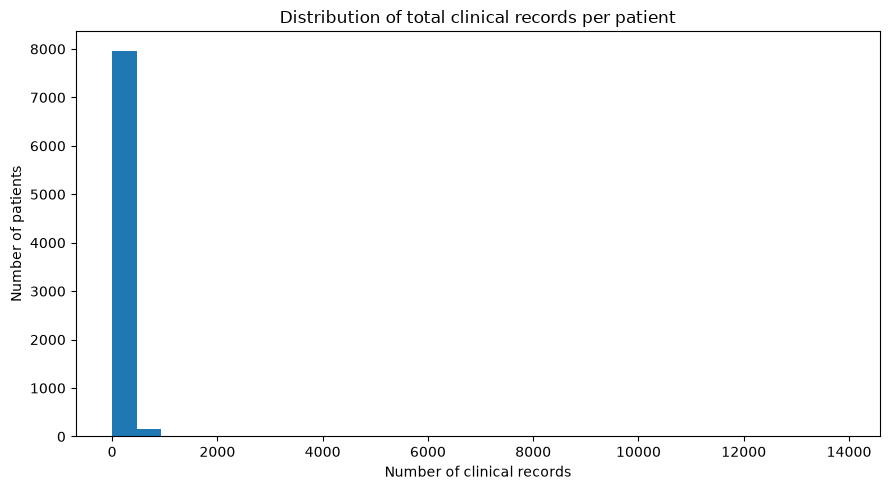

In [30]:
# Count all non-patient clinical records for each patient

patient_record_counts = {}

for name, df in tables.items():
    if name == "patients":
        continue

    patient_col = find_patient_column(df)

    if patient_col is not None:
        counts = df.groupby(patient_col).size()

        for patient_id, count in counts.items():
            patient_record_counts[patient_id] = (
                patient_record_counts.get(patient_id, 0) + count
            )

record_density = pd.Series(patient_record_counts, name="clinical_records")

display(record_density.describe())

plt.figure(figsize=(9, 5))
plt.hist(record_density, bins=30)
plt.title("Distribution of total clinical records per patient")
plt.xlabel("Number of clinical records")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.show()


## 16. Data quality checks

A few simple consistency checks can reveal issues before downstream processing.

We will check:

- duplicate rows
- duplicate patient IDs
- whether clinical tables contain patient IDs not present in `patients.csv`


In [31]:
# Duplicate rows
duplicate_summary = []

for name, df in tables.items():
    duplicate_summary.append({
        "table": name,
        "duplicate_rows": df.duplicated().sum(),
        "total_rows": len(df)
    })

display(pd.DataFrame(duplicate_summary))


,table,duplicate_rows,total_rows
0,allergies,0,597
1,careplans,0,3483
2,conditions,0,8376
3,devices,0,78
4,encounters,0,53346
5,imaging_studies,0,855
6,immunizations,0,15478
7,medications,0,42989
8,observations,442,299697
9,organizations,0,1119


In [32]:
# Check patient ID consistency
if patients is not None and patient_id_col:
    known_patients = set(patients[patient_id_col].dropna())

    consistency_results = []

    for name, df in tables.items():
        if name == "patients":
            continue

        patient_col = find_patient_column(df)

        if patient_col is not None:
            referenced = set(df[patient_col].dropna())
            unknown = referenced - known_patients

            consistency_results.append({
                "table": name,
                "unique_patients_referenced": len(referenced),
                "patient_ids_not_in_patients_table": len(unknown)
            })

    display(pd.DataFrame(consistency_results))


,table,unique_patients_referenced,patient_ids_not_in_patients_table
0,allergies,141,0
1,careplans,1054,0
2,conditions,1152,0
3,devices,74,0
4,encounters,1171,0
5,imaging_studies,247,0
6,immunizations,1169,0
7,medications,1107,0
8,observations,1171,0
9,organizations,1119,1119


## 17. EDA Summary

### Dataset structure
- There are 1171 synthetic patients.
- There are 8 clinical tables: encounters, conditions, medications, observations, procedures, careplans, allergies, and immunizations.
- The top 3 tables that contain the most records are observations, encounters, and medications.
- The average patient has 57.7 records, but the median patient has only 1 record. The distribution is extremely right-skewed, with a small number of patients having very large clinical histories. 

### Clinical content
- The top 3 most common conditions are viral sinusitis, acute viral pharyngitis, and acute bronchitis.
- The top 3 most common medications are hydrochlorothiazide, insulin, and 1 ML Epoetin Alfa.
- The top 3 most common observations recorded are pain severity (0-10 verbal scale), diastolic blood pressur, and systolic blood pressure.
- There are 34981 procedure datapoints and 3483 careplan datapoints. 

### Data quality
- The top 3 columns that have substantial missingness include suffix, deathdate, and maiden name. This makes sense as this information might not be relevant to all patients.
- Most of the CSV files do not have duplicate rows. Observations is the only CSV file with duplicate rows, and it has 442 duplicates.

## 18. Synthea's Role in the FaithfulMed Project: FHIR Stress Test

### What is FHIR?

FHIR (Fast Healthcare Interoperability Resources) is a standard for representing and exchanging healthcare information in a structured format. Instead of storing an entire patient's medical history as one large document, FHIR organizes information into different types of resources, such as Patient, Condition, MedicationRequest, Observation, Procedure, Encounter, and CarePlan. 

Synthea can generate complete synthetic patient records in FHIR format. This makes it useful for FaithfulMed because our project ultimately needs to work with the types of clinical information found in real patient records, while avoiding the use of real patient data. The project README identifies Synthea specifically as the dataset for a FHIR stress test involving discharge summaries and care plans. 

FHIR provides a way to represent the source patient information that could eventually be fed into the FaithfulMed pipeline. The project README specifically notes that raw FHIR is too nested and verbose to send directly to an LLM, so a FHIR flattener should first convert it into a more manageable representation.

### What is a FHIR stress test?

A FHIR stress test would test whether FaithfulMed can handle the complexity of a realistic patient record rather than only relatively small, isolated pieces of clinical text.

In simple terms, we want to ask:

> **Can FaithfulMed take a large, complicated patient record, identify the information that matters, and explain it to a doctor without losing or changing important facts?**

This is particularly relevant to Synthea because our EDA shows that patients can have very different amounts of clinical information. Some patients have only a few records, while others have thousands. This variation allows us to test how the pipeline behaves as the amount and complexity of patient information increases.

The stress test would focus on the input and processing stages of FaithfulMed rather than replacing the project's primary evaluation dataset. MedAESQA remains the primary dataset for evaluating faithfulness and calibrating the Verifier, while Synthea can provide a more realistic, longitudinal patient-record setting for testing the pipeline's ability to process FHIR data.

## 19. Next steps

1. **Inspect Synthea FHIR records** to understand how patient information is represented across resources such as Conditions, Medications, Observations, Procedures, Encounters, and CarePlans.
2. **Identify the FHIR information relevant to FaithfulMed**, particularly information that would be needed to generate discharge summaries or care-plan explanations.
3. **Build a FHIR parser/flattener** that converts the nested FHIR resources into a simpler, structured representation that can be processed by the FaithfulMed pipeline.
4. **Create stress-test cases with different levels of complexity**, ranging from patients with relatively small records to patients with very large numbers of clinical records. The strong variation in record counts observed during this EDA makes Synthea particularly useful for this purpose
5. **Run the resulting records through the FaithfulMed pipeline**, beginning with the Extractor and continuing through the Simplifier, Verifier, Refiner, and Readability agents.
